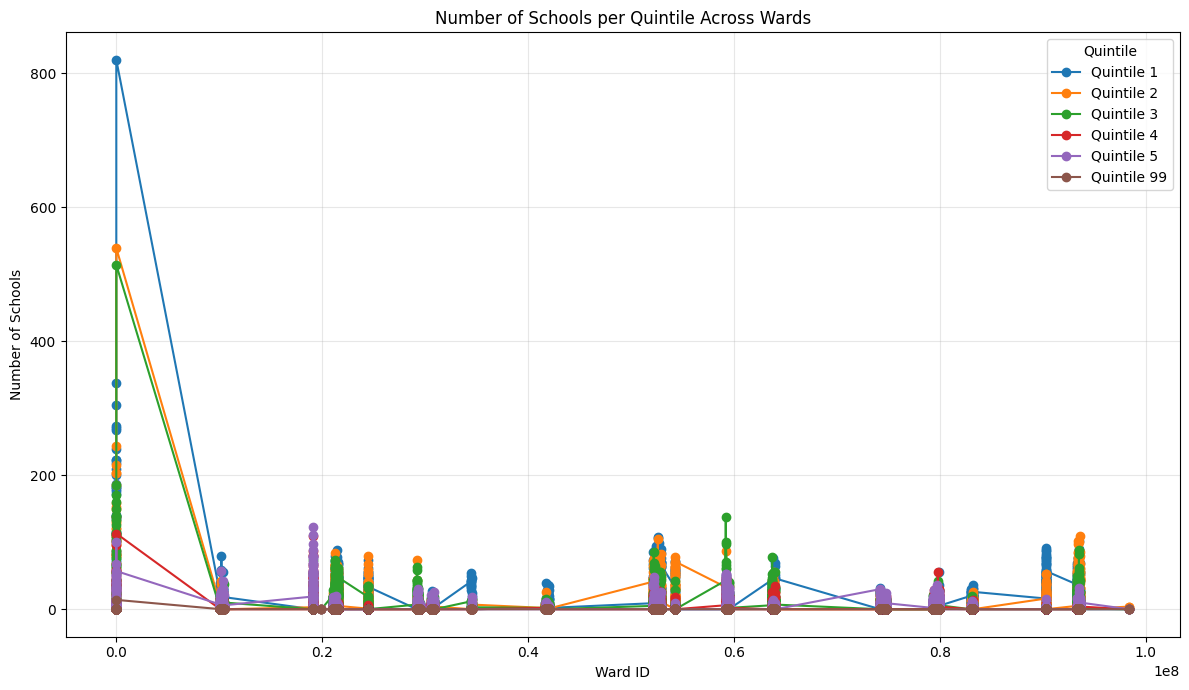

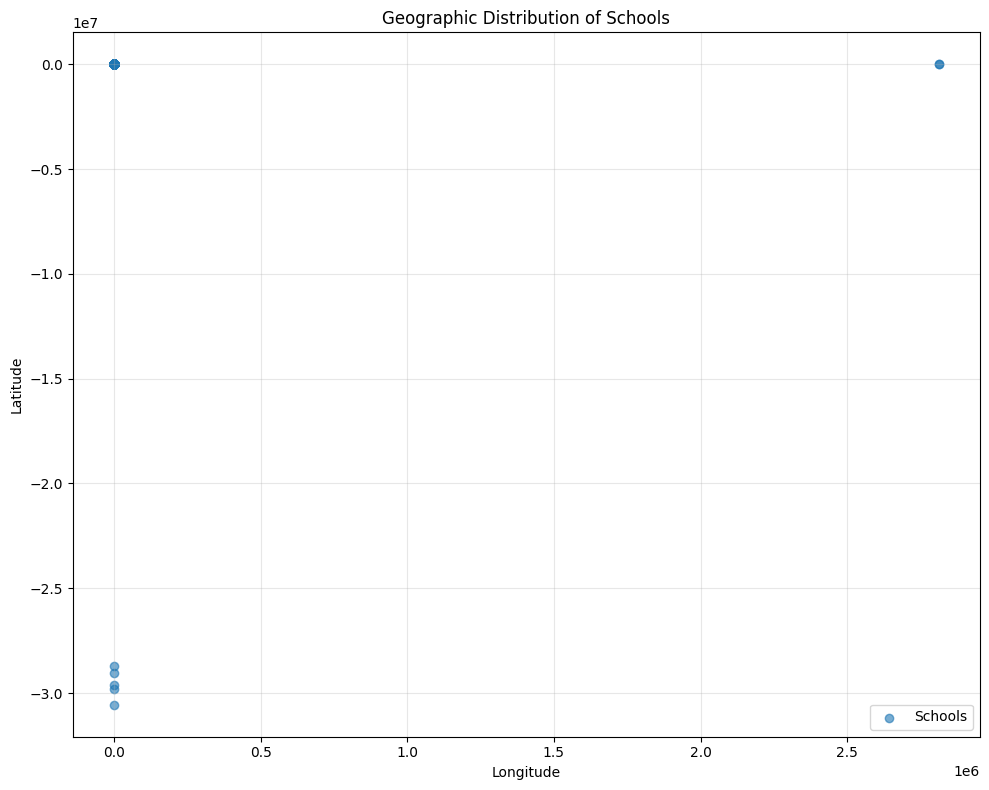

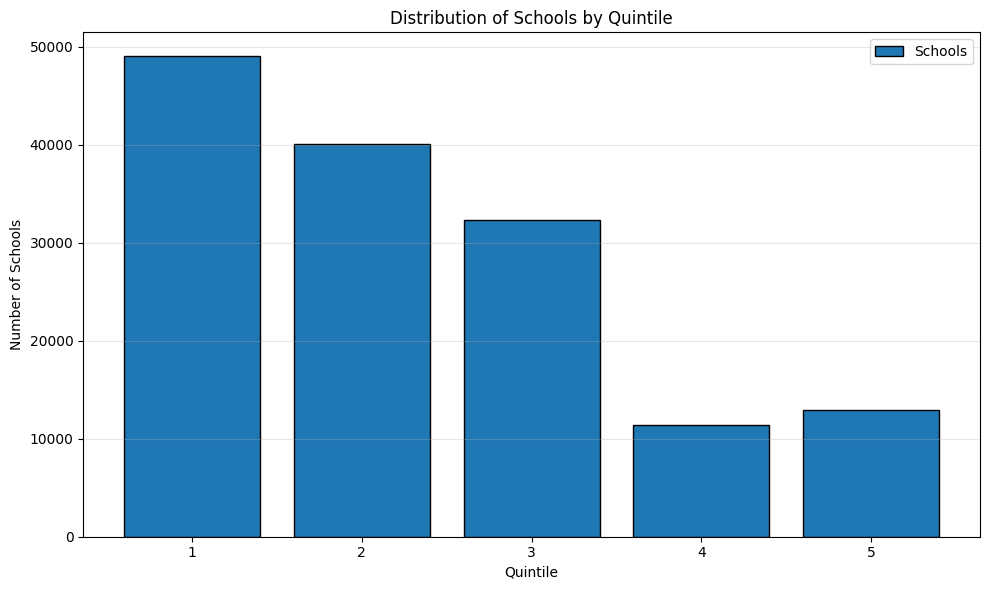

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# LOAD THE DATA
# ============================================================

df = pd.read_csv(
    "School_Data_CSV.csv",
    encoding="cp1252",
    low_memory=False
)


# ============================================================
# DATA CLEANING
# ============================================================

# Convert quintile and ward_id to numeric where possible
df["quintile"] = pd.to_numeric(df["quintile"], errors="coerce")
df["ward_id"] = pd.to_numeric(df["ward_id"], errors="coerce")

# Convert geographic coordinates to numeric
df["new_lat"] = pd.to_numeric(df["new_lat"], errors="coerce")
df["new_long"] = pd.to_numeric(df["new_long"], errors="coerce")


# ============================================================
# (a) LINE PLOT:
# Number of schools per quintile across wards
# ============================================================

schools_by_ward_quintile = (
    df.groupby(["ward_id", "quintile"])
      .size()
      .unstack(fill_value=0)
      .sort_index()
)

plt.figure(figsize=(12, 7))

for quintile in schools_by_ward_quintile.columns:
    plt.plot(
        schools_by_ward_quintile.index,
        schools_by_ward_quintile[quintile],
        marker="o",
        label=f"Quintile {int(quintile)}"
    )

plt.xlabel("Ward ID")
plt.ylabel("Number of Schools")
plt.title("Number of Schools per Quintile Across Wards")
plt.legend(title="Quintile")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# (b) SCATTER PLOT:
# Geographic locations of schools
# ============================================================

geo_data = df.dropna(subset=["new_lat", "new_long"])

plt.figure(figsize=(10, 8))

plt.scatter(
    geo_data["new_long"],
    geo_data["new_lat"],
    alpha=0.6,
    label="Schools"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographic Distribution of Schools")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# (c) HISTOGRAM:
# Distribution of schools by quintile
# ============================================================

quintile_data = df["quintile"].dropna()

plt.figure(figsize=(10, 6))

plt.hist(
    quintile_data,
    bins=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5],
    edgecolor="black",
    rwidth=0.8,
    label="Schools"
)

plt.xticks([1, 2, 3, 4, 5])
plt.xlabel("Quintile")
plt.ylabel("Number of Schools")
plt.title("Distribution of Schools by Quintile")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()